Name: Shawn June
Worked with: None

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv('ForeignGifts_edu.csv', low_memory=False)
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


In [2]:
df[df['Institution Name'].str.contains('Virginia', case=False, na=False)]['Institution Name'].value_counts()

Institution Name
Virginia Commonwealth University                     115
University of Virginia                                98
West Virginia University                              33
Virginia Polytechnic Institute & State University     24
Name: count, dtype: int64

In [3]:
uva = df[df['Institution Name'] == 'University of Virginia'].copy()

print("Number of UVA gift records:", len(uva))
print("Total foreign giving to UVA:", uva['Foreign Gift Amount'].sum())
print("Average UVA gift:", uva['Foreign Gift Amount'].mean())

uva.head()

Number of UVA gift records: 98
Total foreign giving to UVA: 22189238
Average UVA gift: 226420.79591836734


,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
26235,26236,374500,University of Virginia,Charlottesville,VA,41822,3565,Monetary Gift,ENGLAND,West Yorkshire Police
26236,26237,374500,University of Virginia,Charlottesville,VA,41870,12265,Contract,ISRAEL,CureTech Ltd
26237,26238,374500,University of Virginia,Charlottesville,VA,41873,8187,Monetary Gift,ISRAEL,Branco Weiss Institute
26238,26239,374500,University of Virginia,Charlottesville,VA,41887,6437,Contract,ISRAEL,NovoCure Ltd
26239,26240,374500,University of Virginia,Charlottesville,VA,41904,216943,Contract,ISRAEL,InSightec-Image Guide Treatment Ltd


In [4]:
uva.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(10)

Country of Giftor
BANGLADESH     4228589
SWEDEN         4007552
TANZANIA       2776447
SWITZERLAND    2000000
ENGLAND        1950666
GUERNSEY       1500000
FINLAND        1008384
BERMUDA         900000
KOREA           862787
SINGAPORE       805000
Name: Foreign Gift Amount, dtype: int64

In [5]:
uva['Country of Giftor'].value_counts().head(10)

Country of Giftor
ENGLAND            31
ISRAEL             12
BANGLADESH         10
SWEDEN             10
FINLAND             7
KOREA               6
FRANCE              5
THE NETHERLANDS     4
TANZANIA            3
GUERNSEY            3
Name: count, dtype: int64

UVA foreign-giving pattern: UVA received the most foreign funding from Bangladesh, approximately $4.23 million, followed by Sweden at approximately $4.01 million. However, England generated the greatest number of individual gift records, with 31, compared with 10 each from Bangladesh and Sweden. This suggests that UVA’s largest funding relationships are concentrated differently from its most frequent foreign-giving relationships.

In [6]:
peer_search = df[
    df['Institution Name'].str.contains(
        'Michigan|North Carolina|Duke|California, Berkeley',
        case=False,
        na=False
    )
]['Institution Name'].value_counts()

peer_search

Institution Name
University of Michigan - Ann Arbor                          715
University of California, Berkeley                          394
University of North Carolina - Chapel Hill                  286
Duke University                                             145
Western Michigan University                                 136
Michigan State University                                    24
North Carolina State University                              14
Central Michigan University                                  12
North Carolina Agricultural & Technical State University      9
University of North Carolina - Charlotte                      5
University of North Carolina -Greensboro                      3
Michigan Technological University                             2
Name: count, dtype: int64

In [7]:
peers = [
    'University of Virginia',
    'University of Michigan - Ann Arbor',
    'University of California, Berkeley',
    'University of North Carolina - Chapel Hill',
    'Duke University'
]

peer_comparison = (
    df[df['Institution Name'].isin(peers)]
    .groupby('Institution Name')
    .agg(
        total_foreign_giving=('Foreign Gift Amount', 'sum'),
        gift_count=('Foreign Gift Amount', 'size'),
        average_gift=('Foreign Gift Amount', 'mean')
    )
    .sort_values('total_foreign_giving', ascending=False)
)

peer_comparison

,total_foreign_giving,gift_count,average_gift
Institution Name,,,
Duke University,343699498,145,2.370341e+06
"University of California, Berkeley",294479904,394,7.474109e+05
University of Michigan - Ann Arbor,287336783,715,4.018696e+05
University of North Carolina - Chapel Hill,41292544,286,1.443795e+05
University of Virginia,22189238,98,2.264208e+05


Peer comparison: UVA received approximately $22.19 million in foreign giving across 98 gift records, the lowest total and lowest gift count among the peer institutions examined. UVA’s average gift of approximately $226,000 exceeds UNC–Chapel Hill’s average, suggesting that UVA’s lower total is driven in part by a smaller number of foreign-giving relationships rather than solely by smaller individual gifts.

In [8]:
institution_totals = df.groupby('Institution Name')['Foreign Gift Amount'].sum()

market_mean = institution_totals.mean()
market_median = institution_totals.median()

uva_total = uva['Foreign Gift Amount'].sum()
uva_rank = (institution_totals > uva_total).sum() + 1

print(f"UVA total: ${uva_total:,.0f}")
print(f"Market mean: ${market_mean:,.0f}")
print(f"Market median: ${market_median:,.0f}")
print(f"UVA rank by total foreign giving: {uva_rank} out of {len(institution_totals)} institutions")

UVA total: $22,189,238
Market mean: $52,202,879
Market median: $6,486,792
UVA rank by total foreign giving: 101 out of 318 institutions


Market comparison: UVA received approximately $22.19 million in foreign giving, compared with an overall institutional mean of approximately $52.20 million and median of approximately $6.49 million. UVA ranks 101st out of 318 institutions by total foreign giving. This places UVA above the typical institution represented by the median, but substantially below the market mean and behind the selected peer institutions, indicating meaningful room for expansion.

In [9]:
peer_names = [
    'University of Michigan - Ann Arbor',
    'University of California, Berkeley',
    'University of North Carolina - Chapel Hill',
    'Duke University'
]

peer_data = df[df['Institution Name'].isin(peer_names)]

peer_country_totals = (
    peer_data.groupby('Country of Giftor')['Foreign Gift Amount']
    .sum()
)

uva_country_totals = (
    uva.groupby('Country of Giftor')['Foreign Gift Amount']
    .sum()
)

opportunities = pd.DataFrame({
    'Peer Total': peer_country_totals,
    'UVA Total': uva_country_totals
}).fillna(0)

opportunities['Gap'] = opportunities['Peer Total'] - opportunities['UVA Total']

opportunities.sort_values('Gap', ascending=False).head(15)

,Peer Total,UVA Total,Gap
Country of Giftor,,,
FRANCE,163415017.0,250383.0,163164634.0
ENGLAND,92431880.0,1950666.0,90481214.0
SWEDEN,78688347.0,4007552.0,74680795.0
CHINA,70859363.0,0.0,70859363.0
SWITZERLAND,56640836.0,2000000.0,54640836.0
JAPAN,49922230.0,265970.0,49656260.0
CANADA,43734288.0,0.0,43734288.0
KAZAKHSTAN,43533449.0,0.0,43533449.0
GERMANY,43466823.0,0.0,43466823.0


Opportunity analysis: The peer comparison reveals several foreign markets where UVA appears substantially underrepresented. The largest gaps include France, England, Sweden, China, Switzerland, Japan, and Canada. China and Canada are particularly notable because the selected peer institutions received approximately $70.9 million and $43.7 million, respectively, while UVA recorded no giving from either country. France also represents a major expansion opportunity, with approximately $163.4 million received by peers compared with only about $0.25 million at UVA. These results suggest UVA could pursue both new markets, such as China and Canada, and deepen existing relationships in countries such as France, England, and Sweden.

In [10]:
target_countries = ['FRANCE', 'CHINA', 'CANADA', 'GERMANY', 'JAPAN']

target_donors = (
    peer_data[peer_data['Country of Giftor'].isin(target_countries)]
    .groupby(['Country of Giftor', 'Giftor Name'])['Foreign Gift Amount']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

target_donors

Country of Giftor  Giftor Name                        
FRANCE             Sanofi-Aventis Recerche                62106706
                   Sanofi-Aventis Recherche               58520202
GERMANY            BASF Corporation                       20887750
FRANCE             Sanofi Aventis Recherche               14225699
                   Airbus S.A.S.                           9000001
CANADA             Li Ka Shing (Canada) Foundation         9000000
                   Shire Human Genetics Therapies, Inc     6178796
CHINA              Frontt Capital Management, Ltd          6127032
FRANCE             Sanofi                                  4345647
CANADA             Sinai Health System                     3340675
JAPAN              Toyota Motor Company, LTD               3286740
CHINA              Duke Kunshan University                 3245335
JAPAN              Honda (Honda R&D Americas, Inc.)        3000000
CHINA              Beijing AutoBrain Technology LLC        3000000
       

Potential donor strategy: The donor-level analysis suggests that UVA should prioritize targeted outreach in France, China, Canada, Germany, and Japan. French peer-school funding is especially concentrated among Sanofi-Aventis-related entities, while Germany shows substantial support from corporations such as BASF and Bayer Healthcare. Canadian opportunities include philanthropic and health-sector organizations such as the Li Ka Shing Foundation and Sinai Health System. Chinese and Japanese peer giving also includes technology, healthcare, and automotive organizations. Rather than pursuing countries broadly, UVA could identify organizations in sectors aligned with its academic strengths and develop targeted institutional partnerships and philanthropic outreach.

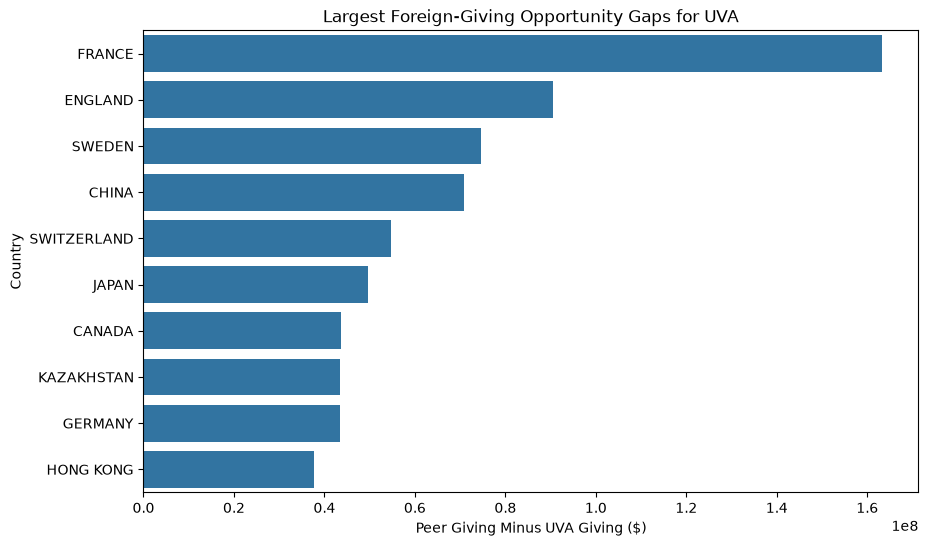

In [11]:
top_gaps = opportunities.sort_values('Gap', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_gaps['Gap'],
    y=top_gaps.index
)

plt.xlabel('Peer Giving Minus UVA Giving ($)')
plt.ylabel('Country')
plt.title('Largest Foreign-Giving Opportunity Gaps for UVA')
plt.show()
